# Greedy Addition

In [73]:
# these warnings are fine. you can ignore them.
import random, math

import sys
sys.path.append('../../../')
from util import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Imports finished.")

Imports finished.


## Setting Up Dataset/Model/Ground Truth

In [31]:
dataset = Dataset(root='/tmp/Cora', name='Cora', device=device)
data, in_feats, h_feats, num_classes = dataset.get_data()

model = get_model('../../../', in_feats, h_feats, num_classes, "cora", Models.GCN)
ground_truth, orig_pred = get_ground_truth(model, data, Models.GCN, testMask=True)
print(ground_truth)

0.745


In [32]:
adj = data.x

## Experiments

**Note:** The ground truth here is $0.745$

In [33]:
homophilic_set = {label: [] for label in set(data.y.tolist())}

# test_indices = torch.nonzero(data.test_mask, as_tuple=False).squeeze()
G, x, y, train_mask, test_mask = convert_to_networkx(dataset.get_data()[0])
for i in G.nodes():
    homophilic_set[data.y[i].item()].append(i)

# print("This is the dictionary containing each class and its respective vertices:\n\t", homophilic_set)

In [34]:
G, x, y, train_mask, test_mask = convert_to_networkx(data)

edge_homo = [0] * len(G.nodes())

for n in G.nodes():
    edge_homo[n] = get_node_homophily(G, n, y, y[n].item())

In [35]:
valid_adds = []

for i in G.nodes:
    for j in G.nodes:
        if i != j and not G.has_edge(i, j):
            valid_adds.append((i, j))

In [37]:
ptb_rate = [(i+1) * 0.05 for i in range(int(1.05 / 0.05) + 1)]
change = 0.000
results = []
for ptb in ptb_rate:
    random.shuffle(valid_adds)
    data = dataset.get_data()[0]
    modified_graph = data
    
    init_edges = len(modified_graph.edge_index[1])
    
    G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)

    budget = math.floor(ptb * G.number_of_edges() * 1/2)
    added = 0
    loc = 0

    while added < budget and loc < len(valid_adds):
        if added % 50 == 0:
            print(added, " iterations!")
   
        new_G = G.copy()
        
        # add edge
        edge = valid_adds[loc]
        add_edge(new_G, edge[0], edge[1], undirected=True)

        # check accuracy
        acc, pred = test_model(model, convert_to_pyg(new_G, x, y, train_mask, test_mask), GCNtype=Models.GCN, testMask=True)
        # print(acc)
        
        # if accuracy is still below threshold, swap graphs and add
        if abs(acc - ground_truth) <= change:
            G = new_G
            added += 1

        loc += 1
    
    modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
    final_edges = len(modified_graph.edge_index[1])
        
    output_accuracy_change(ground_truth, test_model(model, modified_graph, GCNtype=Models.GCN, testMask=True)[0]) 
    number_added_edges(init_edges, final_edges, is_undirected=True)
    results.append(loc)
    print(results)
    # print("Number of k-hops considered:", z)

0  iterations!
0  iterations!
50  iterations!
100  iterations!
150  iterations!
200  iterations!
250  iterations!

----
The accuracy has not changed.
Change in edges:  263.0  | Percentage change: 4.98%
[290]
0  iterations!
50  iterations!
100  iterations!
100  iterations!
150  iterations!
200  iterations!
250  iterations!
300  iterations!
350  iterations!
400  iterations!
450  iterations!
500  iterations!

----
The accuracy has not changed.
Change in edges:  527.0  | Percentage change: 9.98%
[290, 567]
0  iterations!
50  iterations!
100  iterations!
150  iterations!
200  iterations!
250  iterations!
300  iterations!
350  iterations!
400  iterations!
450  iterations!
500  iterations!
550  iterations!
600  iterations!
650  iterations!
700  iterations!
750  iterations!
750  iterations!

----
The accuracy has not changed.
Change in edges:  791.0  | Percentage change: 14.99%
[290, 567, 868]
0  iterations!
50  iterations!
100  iterations!
150  iterations!
200  iterations!
250  iterations!
30

KeyboardInterrupt: 

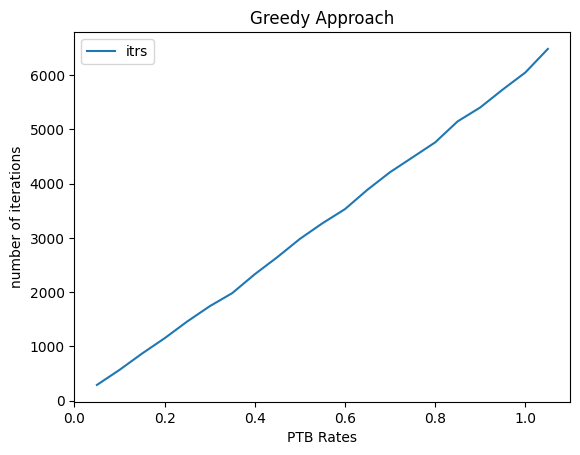

In [39]:
# Plotting
ptb_rate = [(i+1) * 0.05 for i in range(int(1.05 / 0.05))]
plt.plot(ptb_rate, results, label="itrs")

plt.xlabel('PTB Rates')
plt.ylabel('number of iterations')
plt.title('Greedy Approach')
plt.legend()

output_path = f"./data/using_incorrect_w_o_test_mask_graph.png"
plt.savefig(output_path)

# Show plot
plt.show()

In [40]:
import os

def save_data(file_path, data):
    # Automatically create the directory if it doesn't exist
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    # Save the data to the file
    np.save(file_path, data)

# Assuming 'dataset' is a variable you have already defined
dataset_paths = [
    f'./data-arrays/itr_results/gcn_results.npy',
]

results = [
    np.array(results),
]

# Save each results array to its corresponding file
for path, data in zip(dataset_paths, results):
    save_data(path, data)

In [41]:
### what if you look at the set of edges you can't add...

In [43]:
dataset = Dataset(root='/tmp/Cora', name='Cora', device=device)
data, in_feats, h_feats, num_classes = dataset.get_data()

model = get_model('../../../', in_feats, h_feats, num_classes, "cora", Models.GCN)
ground_truth, orig_pred = get_ground_truth(model, data, Models.GCN, testMask=False)
print(ground_truth)

0.7544313146233382


In [44]:
G, x, y, train_mask, test_mask = convert_to_networkx(data)

for i in G.nodes:
    for j in G.nodes:
        if i != j and not G.has_edge(i, j):
            valid_adds.append((i, j))

In [48]:
ptb_rate = [(i+1) * 0.05 for i in range(int(0.5 / 0.05))]
change = 0.000
results = []
for ptb in ptb_rate:
    random.shuffle(valid_adds)
    data = dataset.get_data()[0]
    modified_graph = data
    
    init_edges = len(modified_graph.edge_index[1])
    
    G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)

    budget = math.floor(ptb * G.number_of_edges() * 1/2)
    added = 0
    loc = 0

    while added < budget and loc < len(valid_adds):
        if added % 50 == 0:
            print(added, " iterations!")
   
        new_G = G.copy()
        
        # add edge
        edge = valid_adds[loc]
        add_edge(new_G, edge[0], edge[1], undirected=True)

        # check accuracy
        acc, pred = test_model(model, convert_to_pyg(new_G, x, y, train_mask, test_mask), GCNtype=Models.GCN, testMask=False)
        # print(acc)
        
        # if accuracy is still below threshold, swap graphs and add
        if abs(acc - ground_truth) <= change:
            G = new_G
            added += 1

        loc += 1
    
    modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
    final_edges = len(modified_graph.edge_index[1])
        
    output_accuracy_change(ground_truth, test_model(model, modified_graph, GCNtype=Models.GCN, testMask=False)[0]) 
    number_added_edges(init_edges, final_edges, is_undirected=True)
    results.append(loc)
    print(results)
    # print("Number of k-hops considered:", z)

0  iterations!
50  iterations!
100  iterations!
150  iterations!
200  iterations!
250  iterations!
250  iterations!
250  iterations!
250  iterations!

----
The accuracy has not changed.
Change in edges:  263.0  | Percentage change: 4.98%
[314]
0  iterations!
50  iterations!
100  iterations!
100  iterations!
150  iterations!
200  iterations!
250  iterations!
300  iterations!
350  iterations!
400  iterations!
400  iterations!
450  iterations!
500  iterations!

----
The accuracy has not changed.
Change in edges:  527.0  | Percentage change: 9.98%
[314, 653]
0  iterations!
50  iterations!
50  iterations!
100  iterations!
150  iterations!
200  iterations!
250  iterations!
250  iterations!
300  iterations!
350  iterations!
400  iterations!
450  iterations!
500  iterations!
500  iterations!
500  iterations!
550  iterations!
600  iterations!
600  iterations!
650  iterations!
700  iterations!
750  iterations!

----
The accuracy has not changed.
Change in edges:  790.0  | Percentage change: 14.9

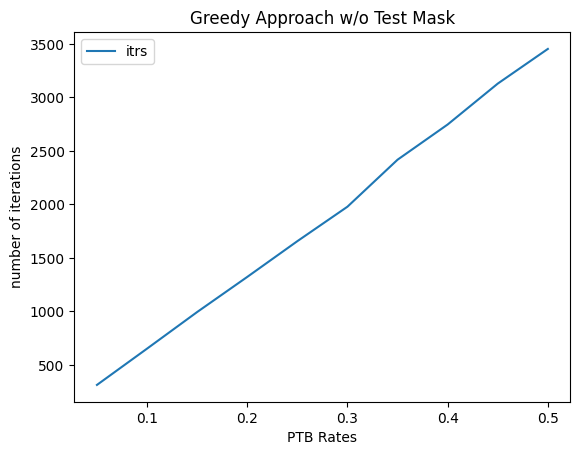

In [49]:
# Plotting
plt.plot(ptb_rate, results, label="itrs")

plt.xlabel('PTB Rates')
plt.ylabel('number of iterations')
plt.title('Greedy Approach w/o Test Mask')
plt.legend()

output_path = f"./data/greedyitrs_wo_test_mask.png"
plt.savefig(output_path)

# Show plot
plt.show()

In [50]:
import os

def save_data(file_path, data):
    # Automatically create the directory if it doesn't exist
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    # Save the data to the file
    np.save(file_path, data)

# Assuming 'dataset' is a variable you have already defined
dataset_paths = [
    f'./data-arrays/itr_results/gcn_results_wo_mask.npy',
]

results = [
    np.array(results),
]

# Save each results array to its corresponding file
for path, data in zip(dataset_paths, results):
    save_data(path, data)

In [71]:
from sklearn.linear_model import LinearRegression

ptb_rate = [[math.floor((i+1) * 0.05 * G.number_of_edges() * 1/2)] for i in range(int(0.5 / 0.05))]

# Example data
x_values = ptb_rate  # Example x values
# print(x_values)
y_values = np.array(results).reshape(-1, 1)  # Corresponding y values
# print(y_values)

# Initialize and fit the model
model = LinearRegression()
model.fit(x_values, y_values)

# Get the parameters of the linear regression model
intercept = model.intercept_
slope = model.coef_[0]

print("slope: ", slope, " - intercept: ", intercept)

slope:  [1.33034894]  - intercept:  [-63.53631772]


In [72]:
data = dataset.get_data()[0]
modified_graph = data
    
G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)

ptb_vals = [[math.floor((i+1) * 0.05 * G.number_of_edges() * 1/2)] for i in range(int(1 / 0.05) + 1)]

y_vals = np.load('./data-arrays/itr_results/gcn_results.npy')

model2 = LinearRegression()
model2.fit(ptb_vals, y_vals)

# Get the parameters of the linear regression model
intercept2 = model2.intercept_
slope2 = model2.coef_[0]

print("slope: ", slope2, " - intercept: ", intercept2)

slope:  1.1608520402081657  - intercept:  -84.9091763203769


## using rejected edges

In [74]:
dataset = Dataset(root='/tmp/Cora', name='Cora', device=device)
data, in_feats, h_feats, num_classes = dataset.get_data()

model = get_model('../../../', in_feats, h_feats, num_classes, "cora", Models.GCN)
ground_truth, orig_pred = get_ground_truth(model, data, Models.GCN, testMask=False)
print(ground_truth)

G, x, y, train_mask, test_mask = convert_to_networkx(data)

for i in G.nodes:
    for j in G.nodes:
        if i != j and not G.has_edge(i, j):
            valid_adds.append((i, j))

0.7544313146233382


In [76]:
ptb_rate = [(i+1) * 0.05 for i in range(int(0.5 / 0.05))]
change = 0.000
results = []
for ptb in ptb_rate:
    random.shuffle(valid_adds)
    data = dataset.get_data()[0]
    modified_graph = data
    
    init_edges = len(modified_graph.edge_index[1])
    
    G, x, y, train_mask, test_mask = convert_to_networkx(modified_graph)

    old_G = G
    rejected_edges = []

    budget = math.floor(ptb * G.number_of_edges() * 1/2)
    added = 0
    loc = 0

    while added < budget and loc < len(valid_adds):
        if added % 50 == 0:
            print(added, " iterations!")
   
        new_G = G.copy()
        
        # add edge
        edge = valid_adds[loc]
        add_edge(new_G, edge[0], edge[1], undirected=True)

        # check accuracy
        acc, pred = test_model(model, convert_to_pyg(new_G, x, y, train_mask, test_mask), GCNtype=Models.GCN, testMask=False)
        # print(acc)
        
        # if accuracy is still below threshold, swap graphs and add
        if abs(acc - ground_truth) <= change:
            G = new_G
            added += 1
        else:
            rejected_edges.append(valid_adds[loc])

        loc += 1

    for edge in rejected_edges:
        add_edge(old_G, edge[0], edge[1], undirected=True)
    G = old_G
    
    modified_graph = convert_to_pyg(G, x, y, train_mask, test_mask)
    final_edges = len(modified_graph.edge_index[1])
        
    output_accuracy_change(ground_truth, test_model(model, modified_graph, GCNtype=Models.GCN, testMask=False)[0]) 
    number_added_edges(init_edges, final_edges, is_undirected=True)
    results.append(loc)
    print(results)
    # print("Number of k-hops considered:", z)

0  iterations!
50  iterations!
100  iterations!
150  iterations!
200  iterations!
250  iterations!
250  iterations!

----
The accuracy has changed by -0.0041
Change in edges:  74.0  | Percentage change: 1.40%
[337]
0  iterations!
50  iterations!
50  iterations!
50  iterations!
100  iterations!
150  iterations!
200  iterations!
200  iterations!
250  iterations!
300  iterations!
350  iterations!
400  iterations!
450  iterations!
500  iterations!

----
The accuracy has changed by -0.0170
Change in edges:  132.0  | Percentage change: 2.50%
[337, 659]
0  iterations!
50  iterations!
100  iterations!
150  iterations!
200  iterations!
250  iterations!
300  iterations!
350  iterations!
400  iterations!
450  iterations!
450  iterations!
500  iterations!
550  iterations!
600  iterations!
600  iterations!
650  iterations!
700  iterations!
750  iterations!

----
The accuracy has changed by -0.0155
Change in edges:  182.0  | Percentage change: 3.45%
[337, 659, 973]
0  iterations!
50  iterations!
50 

realistically, it's possible you can estimate the upper and lower bound in one go...
take the rejected edges and use those as the "upper bound"
take the accepted edges and treat as "lower bound" which is likely just 0 (for a while)